<ipython-input-5-0d7a45928c6d>:15: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['date'] = pd.to_datetime(df['date'], infer_datetime_format=True)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0549 - val_loss: 0.0068
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0187 - val_loss: 0.0586
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0139 - val_loss: 0.0224
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0096 - val_loss: 0.0321
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0102 - val_loss: 0.0239
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0080 - val_loss: 0.0407
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0108 - val_loss: 0.0193
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0078 - val_loss: 0.0501
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0103 - val_loss: 0.0216
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0064 - val_loss: 0.0358
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0074 - val_loss: 0.0280
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0

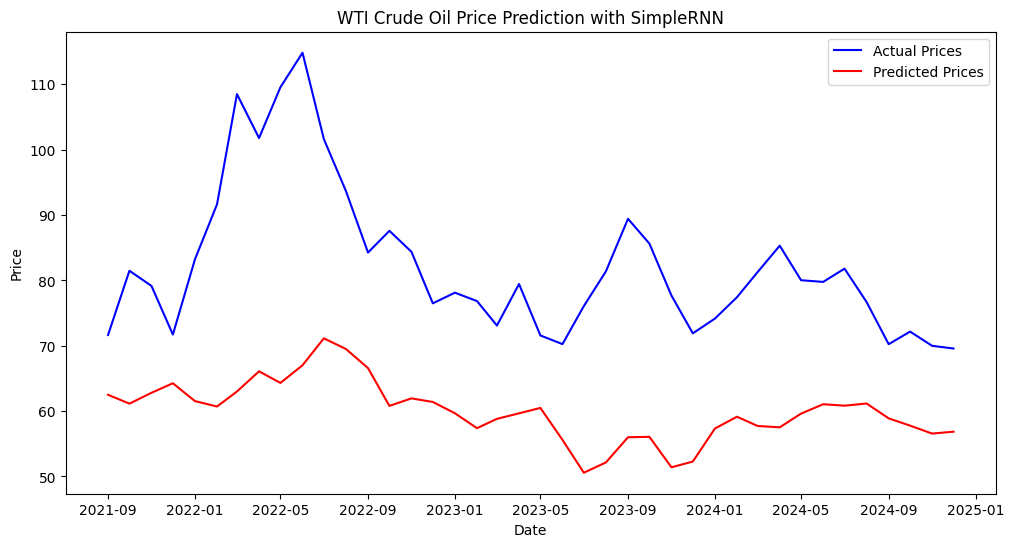

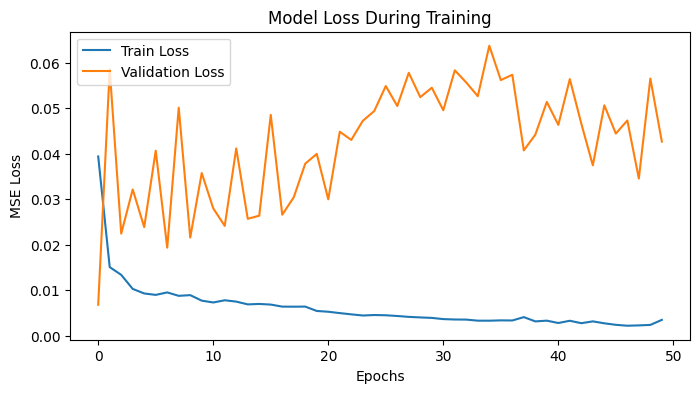

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

# Load dataset
df = pd.read_csv("/content/training_data_20241224.csv")  # Replace with actual filename

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], infer_datetime_format=True)
df.set_index('date', inplace=True)

# Select features and target
features = ['eur_usd', 'inventory', 'production', 'rigs', 'inflation', 'wti_6m_rolling', 'wti_12m_rolling', 'wti_6m_lag']
target = 'wti'

# Scale features and target
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[features + [target]]), columns=features + [target], index=df.index)

# Convert to sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1])  # Features
        y.append(data[i+seq_length, -1])     # Target
    return np.array(X), np.array(y)

seq_length = 30  # 30 days sequence
X, y = create_sequences(df_scaled.values, seq_length)

# Train-test split
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# Build SimpleRNN model
model = Sequential([
    SimpleRNN(50, activation='relu', return_sequences=False, input_shape=(seq_length, X.shape[2])),
    Dense(25, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test), verbose=1)

# Predictions
y_pred = model.predict(X_test)

# Rescale predictions and actual values
y_test_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_test.reshape(-1, 1)), axis=1))[:, -1]
y_pred_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_pred), axis=1))[:, -1]

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
print(f'RMSE: {rmse:.2f}, MAE: {mae:.2f}')

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test):], y_test_inv, label='Actual Prices', color='blue')
plt.plot(df.index[-len(y_test):], y_pred_inv, label='Predicted Prices', color='red')
plt.title('WTI Crude Oil Price Prediction with SimpleRNN')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Plot training history
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - loss: 0.5560 - val_loss: 0.2134 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0921 - val_loss: 0.0108 - learning_rate: 0.0010
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0799 - val_loss: 0.0233 - learning_rate: 0.0010
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0331 - val_loss: 0.0509 - learning_rate: 0.0010
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0422 - val_loss: 0.0306 - learning_rate: 0.0010
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0276 - val_loss: 0.0287 - learning_rate: 0.0010
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0285 - val_loss: 0.0319 - learning_rate: 0.0010
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0269 - val_loss: 0.0267 - learning_rate: 5.0000e-04
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0308 - val_loss: 0.0291 - learning_rate: 5.0000e-04
Epoch 10/50
10/10 ━━━

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 479ms/step
RMSE: 12.18, MAE: 9.51


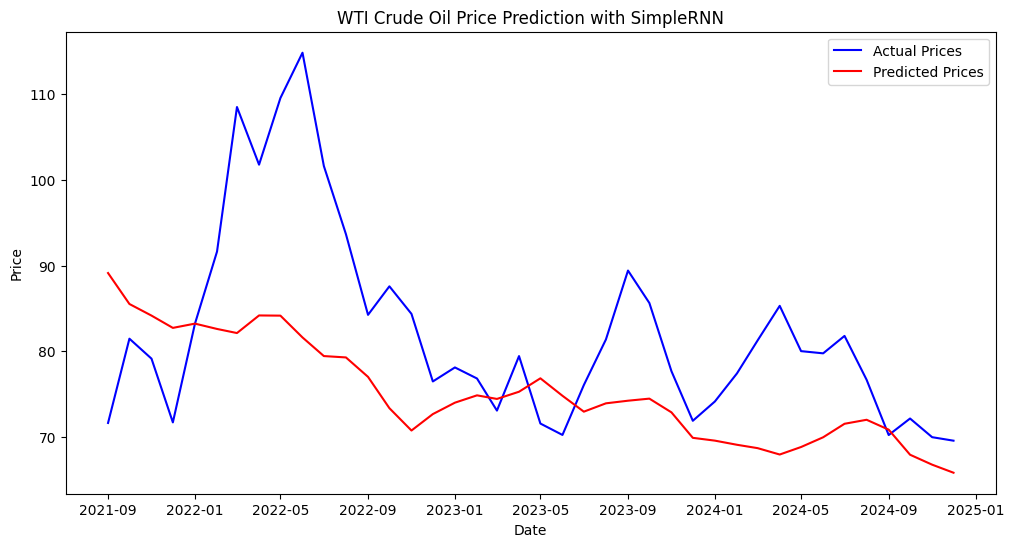

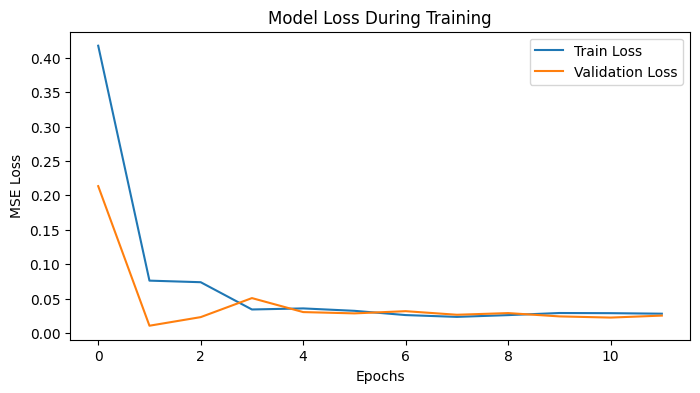

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Load dataset
df = pd.read_csv("/content/training_data_20241224.csv")  # Replace with actual filename

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')  # Ensure correct date format
df.set_index('date', inplace=True)

# Select features and target
features = ['eur_usd', 'inventory', 'production', 'rigs', 'inflation', 'wti_6m_rolling', 'wti_12m_rolling', 'wti_6m_lag']
target = 'wti'

# Scale features and target
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[features + [target]]), columns=features + [target], index=df.index)

# Convert to sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1])  # Features
        y.append(data[i+seq_length, -1])     # Target
    return np.array(X), np.array(y)

seq_length = 30  # 30 days sequence
X, y = create_sequences(df_scaled.values, seq_length)

# Train-test split
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# Build SimpleRNN model
model = Sequential([
    SimpleRNN(50, activation='relu', return_sequences=True, input_shape=(seq_length, X.shape[2])),
    Dropout(0.2),
    SimpleRNN(50, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

# Compile model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse')

# Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test), verbose=1,
                    callbacks=[reduce_lr, early_stopping])

# Predictions
y_pred = model.predict(X_test)

# Rescale predictions and actual values
y_test_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_test.reshape(-1, 1)), axis=1))[:, -1]
y_pred_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_pred), axis=1))[:, -1]

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
print(f'RMSE: {rmse:.2f}, MAE: {mae:.2f}')

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test):], y_test_inv, label='Actual Prices', color='blue')
plt.plot(df.index[-len(y_test):], y_pred_inv, label='Predicted Prices', color='red')
plt.title('WTI Crude Oil Price Prediction with SimpleRNN')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Plot training history
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.4562 - val_loss: 0.0377 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0766 - val_loss: 0.0452 - learning_rate: 0.0010
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0525 - val_loss: 0.0789 - learning_rate: 0.0010
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0435 - val_loss: 0.0755 - learning_rate: 0.0010
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0445 - val_loss: 0.0765 - learning_rate: 0.0010
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0317 - val_loss: 0.0875 - learning_rate: 0.0010
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0339 - val_loss: 0.0815 - learning_rate: 5.0000e-04
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0382 - val_loss: 0.0715 - learning_rate: 5.0000e-04
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0212 - val_loss: 0.0775 - learning_rate: 5.0000e-04
Epoch 1

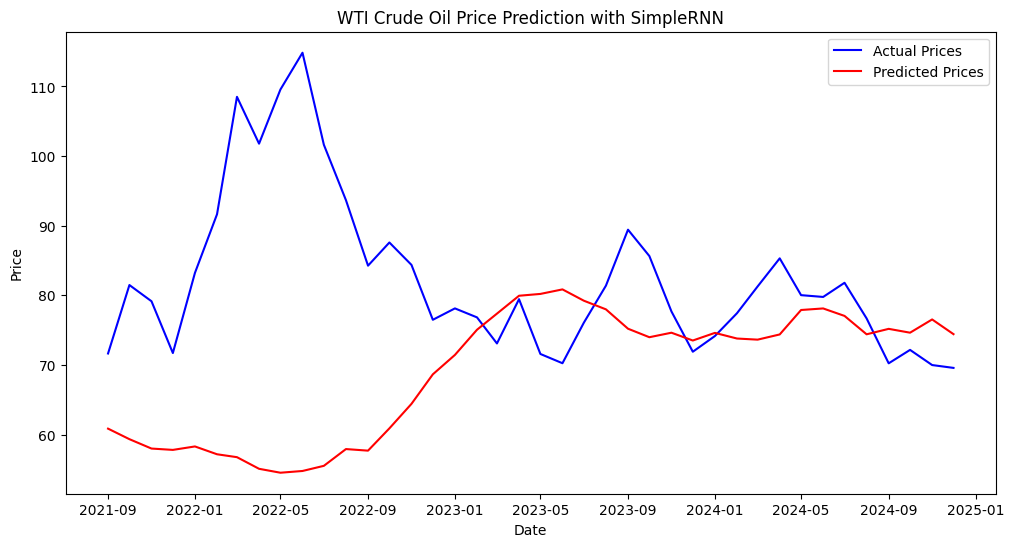

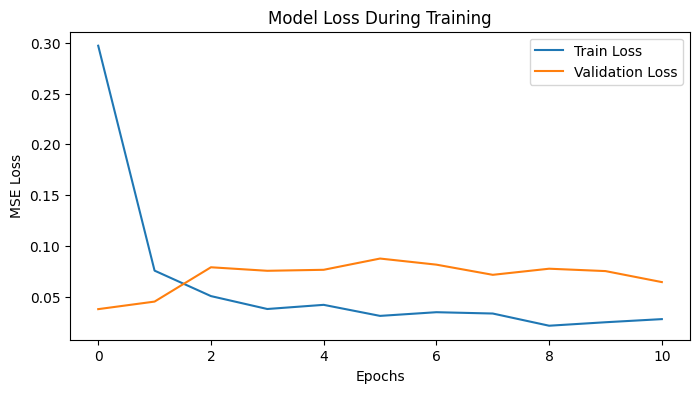

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Load dataset
df = pd.read_csv("/content/training_data_20241224.csv")  # Replace with actual filename

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')  # Ensure correct date format
df.set_index('date', inplace=True)

# Select features and target
features = ['eur_usd', 'inventory', 'production', 'rigs', 'inflation', 'wti_6m_rolling', 'wti_12m_rolling', 'wti_6m_lag']
target = 'wti'

# Scale features and target
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[features + [target]]), columns=features + [target], index=df.index)

# Convert to sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1])  # Features
        y.append(data[i+seq_length, -1])     # Target
    return np.array(X), np.array(y)

seq_length = 30  # 30 days sequence
X, y = create_sequences(df_scaled.values, seq_length)

# Train-test split
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# Build SimpleRNN model
model = Sequential([
    SimpleRNN(50, activation='relu', return_sequences=True, input_shape=(seq_length, X.shape[2])),
    Dropout(0.2),
    SimpleRNN(50, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

# Compile model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse')

# Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test), verbose=1,
                    callbacks=[reduce_lr, early_stopping])

# Predictions
y_pred = model.predict(X_test)

# Rescale predictions and actual values
y_test_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_test.reshape(-1, 1)), axis=1))[:, -1]
y_pred_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_pred), axis=1))[:, -1]

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mean_price = np.mean(y_test_inv)

rmse_pct = (rmse / mean_price) * 100
mae_pct = (mae / mean_price) * 100

print(f'RMSE: {rmse:.2f} ({rmse_pct:.2f}%)')
print(f'MAE: {mae:.2f} ({mae_pct:.2f}%)')

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test):], y_test_inv, label='Actual Prices', color='blue')
plt.plot(df.index[-len(y_test):], y_pred_inv, label='Predicted Prices', color='red')
plt.title('WTI Crude Oil Price Prediction with SimpleRNN')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Plot training history
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - loss: 0.3436 - val_loss: 0.5011 - learning_rate: 0.0010
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.2330 - val_loss: 0.2252 - learning_rate: 0.0010
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.1681 - val_loss: 0.2593 - learning_rate: 0.0010
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.1689 - val_loss: 0.1906 - learning_rate: 0.0010
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.1015 - val_loss: 0.0982 - learning_rate: 0.0010
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.1067 - val_loss: 0.0751 - learning_rate: 0.0010
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0974 - val_loss: 0.1126 - learning_rate: 0.0010
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.1185 - val_loss: 0.0252 - learning_rate: 0.0010
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0778 - val_loss: 0.1266 - learning_rate: 0.0010
Epoch 10/100
9/9 ━━━━━━━━━━

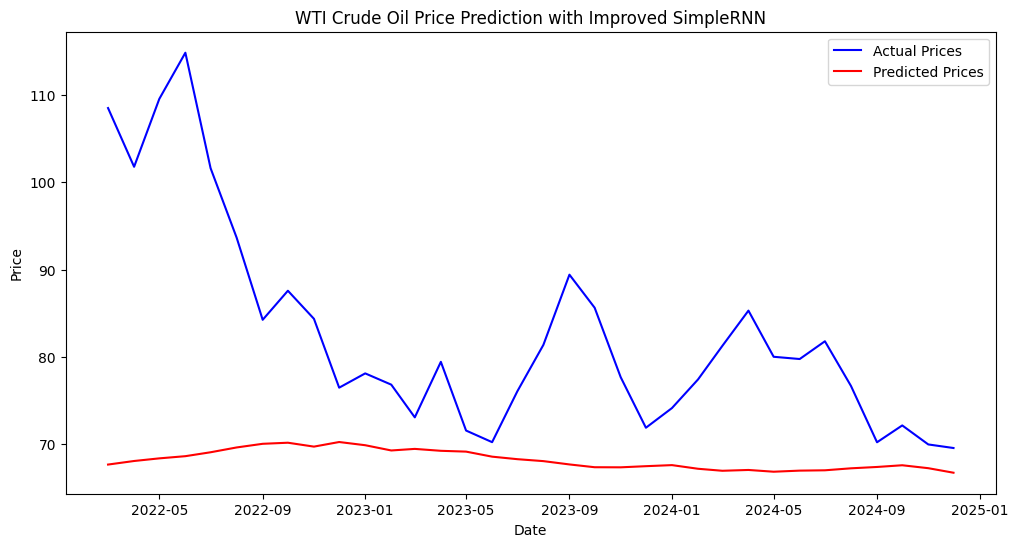

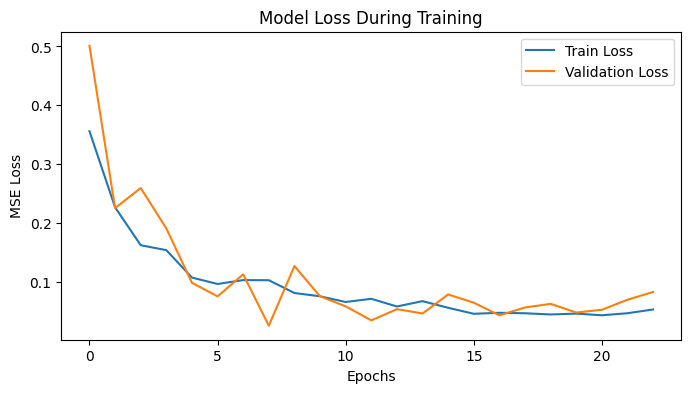

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Load dataset
df = pd.read_csv("/content/training_data_20241224.csv")  # Replace with actual filename

df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')  # Convert date column
df.set_index('date', inplace=True)

# Select features and target
features = ['eur_usd', 'inventory', 'production', 'rigs', 'inflation', 'wti_6m_rolling', 'wti_12m_rolling', 'wti_6m_lag']
target = 'wti'

# Scale features and target
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[features + [target]]), columns=features + [target], index=df.index)

# Convert to sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1])  # Features
        y.append(data[i+seq_length, -1])     # Target
    return np.array(X), np.array(y)

seq_length = 60  # Increased to 60 days for long-term patterns
X, y = create_sequences(df_scaled.values, seq_length)

# Train-test split
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# Build Improved SimpleRNN model
model = Sequential([
    SimpleRNN(128, activation='tanh', return_sequences=True, input_shape=(seq_length, X.shape[2])),
    Dropout(0.3),
    SimpleRNN(128, activation='tanh', return_sequences=True),
    Dropout(0.3),
    SimpleRNN(64, activation='tanh', return_sequences=False),
    Dropout(0.3),
    Dense(50, activation='relu'),
    Dense(1)
])

# Compile model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse')

# Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test), verbose=1,
                    callbacks=[reduce_lr, early_stopping])

# Predictions
y_pred = model.predict(X_test)

# Rescale predictions and actual values
y_test_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_test.reshape(-1, 1)), axis=1))[:, -1]
y_pred_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_pred), axis=1))[:, -1]

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
percentage_rmse = (rmse / np.mean(y_test_inv)) * 100
percentage_mae = (mae / np.mean(y_test_inv)) * 100

print(f'RMSE: {rmse:.2f} ({percentage_rmse:.2f}%)')
print(f'MAE: {mae:.2f} ({percentage_mae:.2f}%)')

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test):], y_test_inv, label='Actual Prices', color='blue')
plt.plot(df.index[-len(y_test):], y_pred_inv, label='Predicted Prices', color='red')
plt.title('WTI Crude Oil Price Prediction with Improved SimpleRNN')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Plot training history
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 220ms/step - loss: 0.7659 - val_loss: 0.0181 - learning_rate: 0.0010
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.3715 - val_loss: 0.0699 - learning_rate: 0.0010
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - loss: 0.3006 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.3249 - val_loss: 0.2698 - learning_rate: 0.0010
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 0.2001 - val_loss: 0.1031 - learning_rate: 0.0010
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 0.1816 - val_loss: 0.1826 - learning_rate: 0.0010
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - loss: 0.1837 - val_loss: 0.2095 - learning_rate: 0.0010
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 0.1692 - val_loss: 0.0659 - learning_rate: 0.0010
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - loss: 0.1605 - val_loss: 0.0780 - learning_rate: 5.0000e-04
Epoch 10/100
7/7 ━━━━━━━━━━

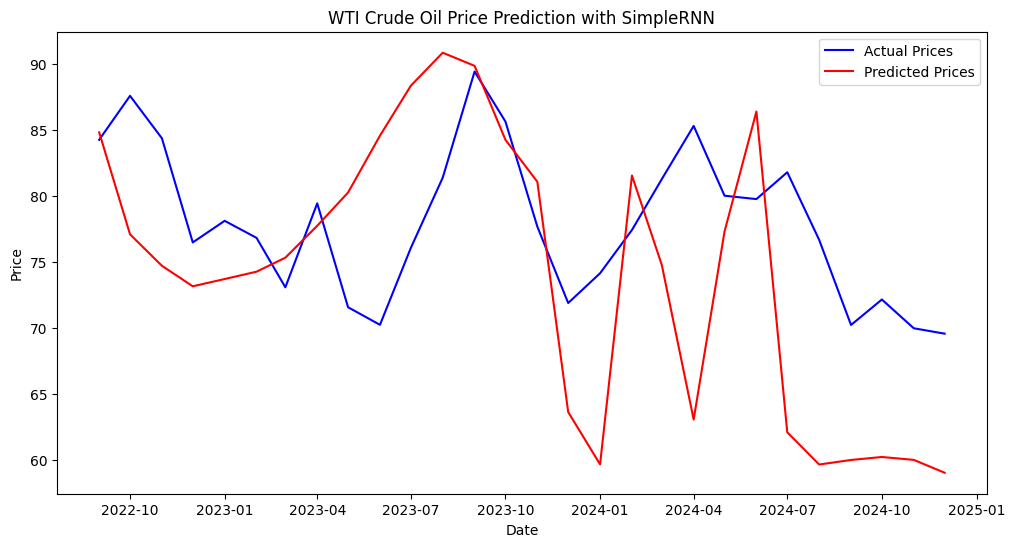

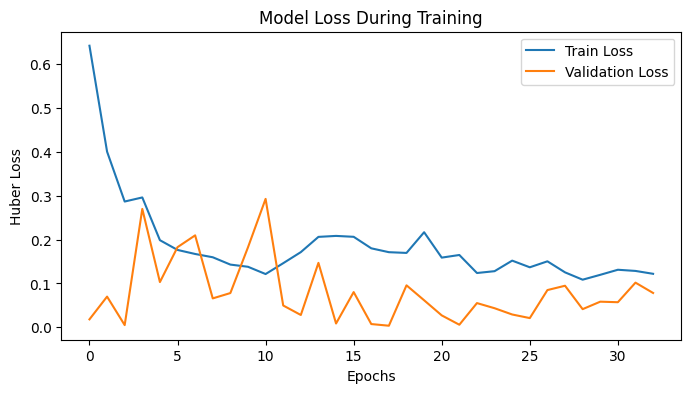

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.losses import Huber

# Load dataset
df = pd.read_csv("/content/training_data_20241224.csv")  # Replace with actual filename

df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')  # Convert date column
df.set_index('date', inplace=True)

# Select features and target
features = ['eur_usd', 'inventory', 'production', 'rigs', 'inflation', 'wti_6m_rolling', 'wti_12m_rolling', 'wti_6m_lag']
target = 'wti'

# Scale features and target
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[features + [target]]), columns=features + [target], index=df.index)

# Convert to sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1])  # Features
        y.append(data[i+seq_length, -1])     # Target
    return np.array(X), np.array(y)

seq_length = 90  # Increased to 90 days for better trend capture
X, y = create_sequences(df_scaled.values, seq_length)

# Train-test split
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# Build Enhanced SimpleRNN model
model = Sequential([
    SimpleRNN(128, activation='tanh', return_sequences=True, input_shape=(seq_length, X.shape[2])),
    BatchNormalization(),
    Dropout(0.3),
    SimpleRNN(128, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    SimpleRNN(64, activation='tanh', return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(50, activation='relu'),
    Dense(1)
])

# Compile model
optimizer = RMSprop(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=Huber(delta=1.0))

# Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test), verbose=1,
                    callbacks=[reduce_lr, early_stopping])

# Predictions
y_pred = model.predict(X_test)

# Rescale predictions and actual values
y_test_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_test.reshape(-1, 1)), axis=1))[:, -1]
y_pred_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_pred), axis=1))[:, -1]

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
percentage_rmse = (rmse / np.mean(y_test_inv)) * 100
percentage_mae = (mae / np.mean(y_test_inv)) * 100

print(f'RMSE: {rmse:.2f} ({percentage_rmse:.2f}%)')
print(f'MAE: {mae:.2f} ({percentage_mae:.2f}%)')

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test):], y_test_inv, label='Actual Prices', color='blue')
plt.plot(df.index[-len(y_test):], y_pred_inv, label='Predicted Prices', color='red')
plt.title('WTI Crude Oil Price Prediction with SimpleRNN')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Plot training history
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Huber Loss')
plt.legend()
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 389ms/step - loss: 0.6685 - val_loss: 0.0925 - learning_rate: 0.0010
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 413ms/step - loss: 0.2045 - val_loss: 0.0909 - learning_rate: 0.0010
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 243ms/step - loss: 0.1805 - val_loss: 0.0815 - learning_rate: 0.0010
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step - loss: 0.1609 - val_loss: 0.0705 - learning_rate: 0.0010
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - loss: 0.1159 - val_loss: 0.0448 - learning_rate: 0.0010
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 270ms/step - loss: 0.1183 - val_loss: 0.0346 - learning_rate: 0.0010
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 275ms/step - loss: 0.1365 - val_loss: 0.0205 - learning_rate: 0.0010
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 248ms/step - loss: 0.1229 - val_loss: 0.0257 - learning_rate: 0.0010
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 234ms/step - loss: 0.0922 - val_loss: 0.0232 - learning_rate: 0.0010
Epoch 10/100
7/7 ━

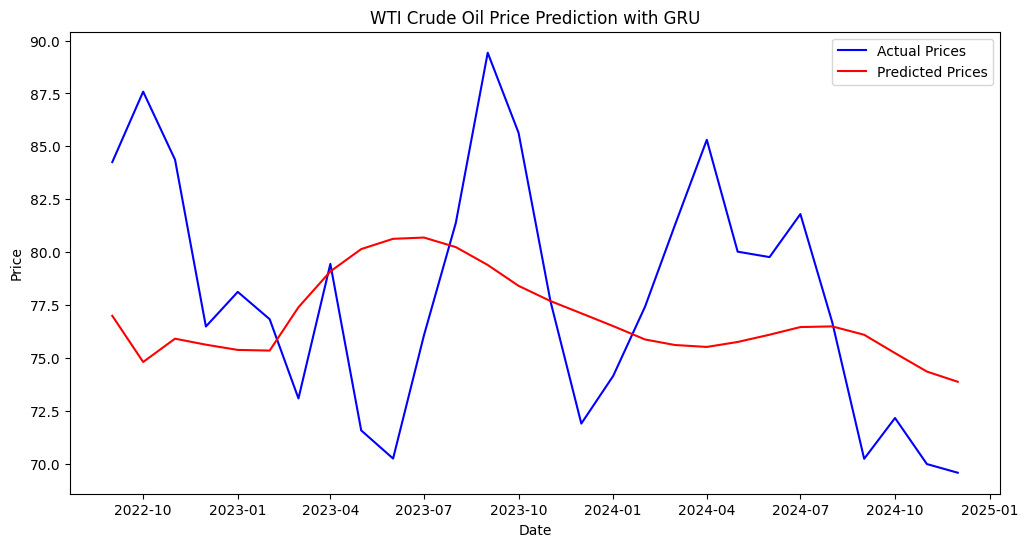

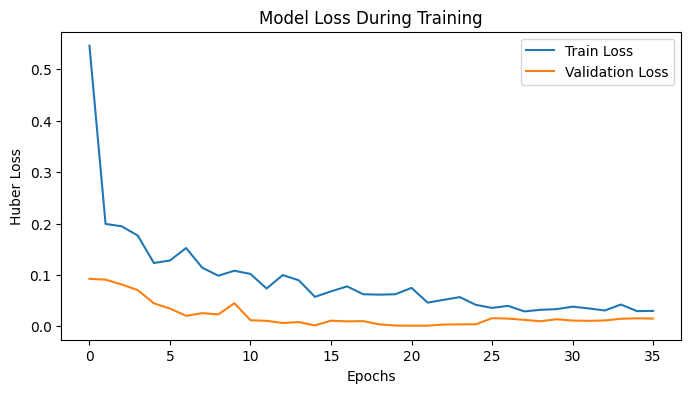

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.losses import Huber

# Ensure reproducibility

# Load dataset
df = pd.read_csv("/content/training_data_20241224.csv")  # Replace with actual filename

df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')  # Convert date column
df.set_index('date', inplace=True)

# Select features and target
features = ['eur_usd', 'inventory', 'production', 'rigs', 'inflation', 'wti_6m_rolling', 'wti_12m_rolling', 'wti_6m_lag']
target = 'wti'

# Scale features and target
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[features + [target]]), columns=features + [target], index=df.index)

# Convert to sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1])  # Features
        y.append(data[i+seq_length, -1])     # Target
    return np.array(X), np.array(y)

seq_length = 90  # Use 90 days for better trend capture
X, y = create_sequences(df_scaled.values, seq_length)

# Train-test split
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# Build GRU model
model = Sequential([
    GRU(128, activation='tanh', return_sequences=True, input_shape=(seq_length, X.shape[2])),
    BatchNormalization(),
    Dropout(0.3),
    GRU(128, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    GRU(64, activation='tanh', return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(50, activation='relu'),
    Dense(1)
])

# Compile model
optimizer = RMSprop(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=Huber(delta=1.0))

# Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test), verbose=1,
                    callbacks=[reduce_lr, early_stopping])

# Predictions
y_pred = model.predict(X_test)

# Rescale predictions and actual values
y_test_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_test.reshape(-1, 1)), axis=1))[:, -1]
y_pred_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_pred), axis=1))[:, -1]

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
percentage_rmse = (rmse / np.mean(y_test_inv)) * 100
percentage_mae = (mae / np.mean(y_test_inv)) * 100

print(f'RMSE: {rmse:.2f} ({percentage_rmse:.2f}%)')
print(f'MAE: {mae:.2f} ({percentage_mae:.2f}%)')

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test):], y_test_inv, label='Actual Prices', color='blue')
plt.plot(df.index[-len(y_test):], y_pred_inv, label='Predicted Prices', color='red')
plt.title('WTI Crude Oil Price Prediction with GRU')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Plot training history
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Huber Loss')
plt.legend()
plt.show()

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 519ms/step - loss: 0.4323 - val_loss: 0.0617 - learning_rate: 0.0010
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 234ms/step - loss: 0.2610 - val_loss: 0.0613 - learning_rate: 0.0010
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 220ms/step - loss: 0.2066 - val_loss: 0.0612 - learning_rate: 0.0010
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - loss: 0.1917 - val_loss: 0.0537 - learning_rate: 0.0010
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - loss: 0.1427 - val_loss: 0.0916 - learning_rate: 0.0010
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 398ms/step - loss: 0.1219 - val_loss: 0.0958 - learning_rate: 0.0010
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 222ms/step - loss: 0.1088 - val_loss: 0.0879 - learning_rate: 0.0010
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step - loss: 0.1019 - val_loss: 0.0779 - learning_rate: 0.0010
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 222ms/step - loss: 0.1254 - val_loss: 0.0562 - learning_rate: 0.0010
Epoch 10/100
7/7 ━━━━━━━━━━━━━

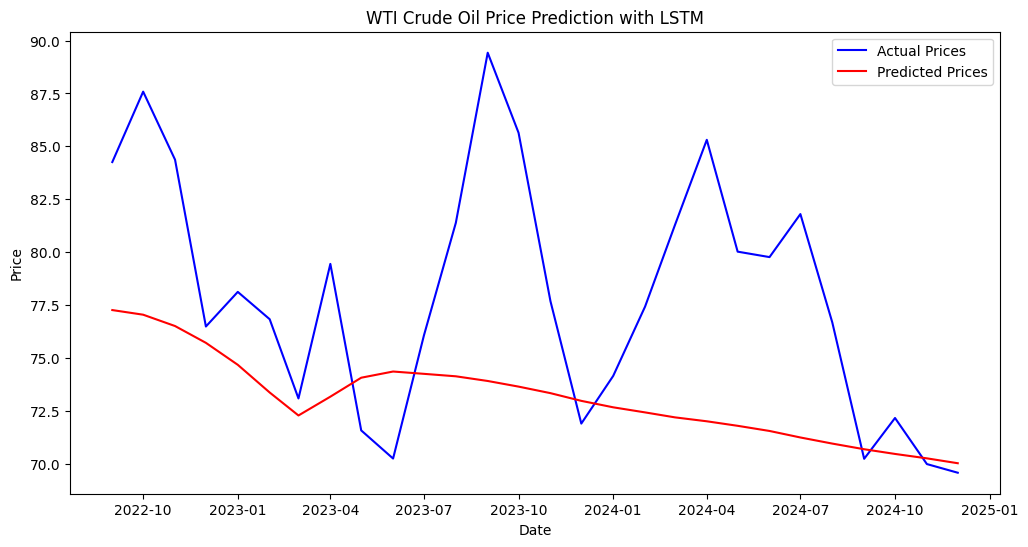

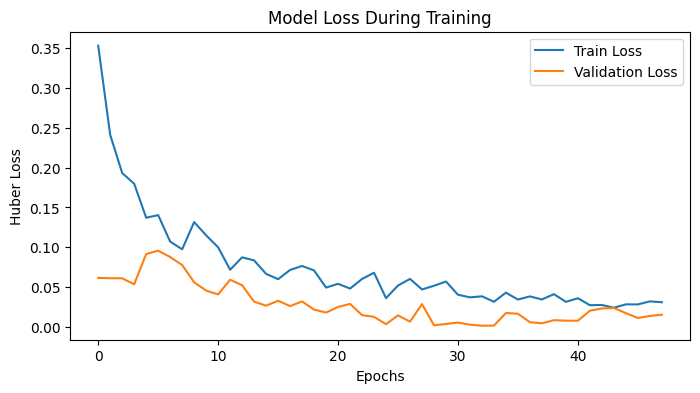

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.losses import Huber


# Load dataset
df = pd.read_csv("/content/training_data_20241224.csv")  # Replace with actual filename
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')  # Convert date column
df.set_index('date', inplace=True)

# Select features and target
features = ['eur_usd', 'inventory', 'production', 'rigs', 'inflation', 'wti_6m_rolling', 'wti_12m_rolling', 'wti_6m_lag']
target = 'wti'

# Scale features and target
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[features + [target]]), columns=features + [target], index=df.index)

# Convert to sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1])  # Features
        y.append(data[i+seq_length, -1])     # Target
    return np.array(X), np.array(y)

seq_length = 90  # Use 90 days for better trend capture
X, y = create_sequences(df_scaled.values, seq_length)

# Train-test split
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# Build LSTM model
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(seq_length, X.shape[2])),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(128, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(64, activation='tanh', return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(50, activation='relu'),
    Dense(1)
])

# Compile model
optimizer = RMSprop(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=Huber(delta=1.0))

# Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test), verbose=1,
                    callbacks=[reduce_lr, early_stopping])

# Predictions
y_pred = model.predict(X_test)

# Rescale predictions and actual values
y_test_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_test.reshape(-1, 1)), axis=1))[:, -1]
y_pred_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_pred), axis=1))[:, -1]

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
percentage_rmse = (rmse / np.mean(y_test_inv)) * 100
percentage_mae = (mae / np.mean(y_test_inv)) * 100

print(f'RMSE: {rmse:.2f} ({percentage_rmse:.2f}%)')
print(f'MAE: {mae:.2f} ({percentage_mae:.2f}%)')

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test):], y_test_inv, label='Actual Prices', color='blue')
plt.plot(df.index[-len(y_test):], y_pred_inv, label='Predicted Prices', color='red')
plt.title('WTI Crude Oil Price Prediction with LSTM')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Plot training history
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Huber Loss')
plt.legend()
plt.show()

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 528ms/step - loss: 0.0751 - val_loss: 0.0042 - learning_rate: 5.0000e-04
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step - loss: 0.0175 - val_loss: 0.0106 - learning_rate: 5.0000e-04
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - loss: 0.0174 - val_loss: 0.0016 - learning_rate: 5.0000e-04
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 219ms/step - loss: 0.0121 - val_loss: 0.0060 - learning_rate: 5.0000e-04
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - loss: 0.0112 - val_loss: 0.0031 - learning_rate: 5.0000e-04
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 370ms/step - loss: 0.0092 - val_loss: 0.0088 - learning_rate: 5.0000e-04
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 227ms/step - loss: 0.0074 - val_loss: 0.0090 - learning_rate: 5.0000e-04
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 224ms/step - loss: 0.0060 - val_loss: 0.0132 - learning_rate: 5.0000e-04
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - loss: 0.0061 - val_loss: 0.0125 - learning_rate: 2.500

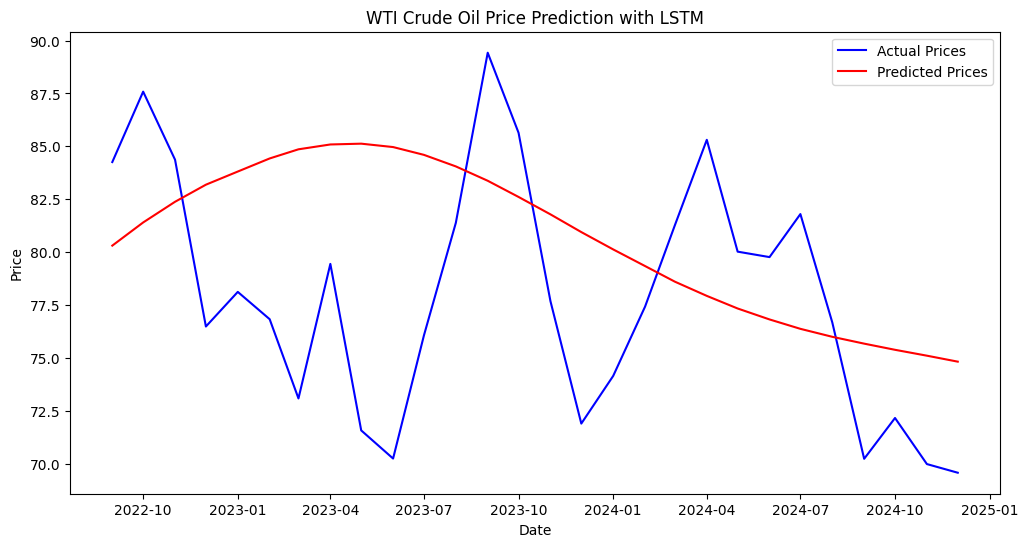

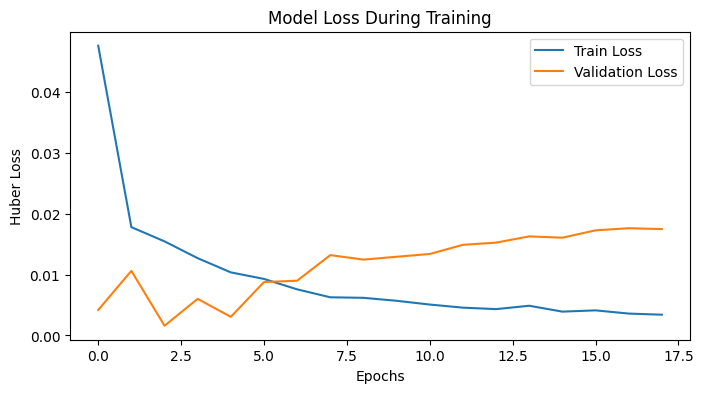

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.losses import Huber


# Load dataset
df = pd.read_csv("/content/training_data_20241224.csv")  # Replace with actual filename
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')  # Convert date column
df.set_index('date', inplace=True)

# Select features and target
features = ['eur_usd', 'inventory', 'production', 'rigs', 'inflation', 'wti_6m_rolling', 'wti_12m_rolling', 'wti_6m_lag']
target = 'wti'

# Scale features and target
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[features + [target]]), columns=features + [target], index=df.index)

# Convert to sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1])  # Features
        y.append(data[i+seq_length, -1])     # Target
    return np.array(X), np.array(y)

seq_length = 90  # Use 90 days for better trend capture
X, y = create_sequences(df_scaled.values, seq_length)

# Train-test split
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# Build LSTM model
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(seq_length, X.shape[2])),
    Dropout(0.3),
    LSTM(128, activation='tanh', return_sequences=True),
    Dropout(0.3),
    LSTM(64, activation='tanh', return_sequences=False),
    Dense(50, activation='relu'),
    Dense(1)
])

# Compile model
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss=Huber(delta=1.0))

# Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test), verbose=1,
                    callbacks=[reduce_lr, early_stopping])

# Predictions
y_pred = model.predict(X_test)

# Rescale predictions and actual values
y_test_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_test.reshape(-1, 1)), axis=1))[:, -1]
y_pred_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_pred), axis=1))[:, -1]

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
percentage_rmse = (rmse / np.mean(y_test_inv)) * 100
percentage_mae = (mae / np.mean(y_test_inv)) * 100

print(f'RMSE: {rmse:.2f} ({percentage_rmse:.2f}%)')
print(f'MAE: {mae:.2f} ({percentage_mae:.2f}%)')

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test):], y_test_inv, label='Actual Prices', color='blue')
plt.plot(df.index[-len(y_test):], y_pred_inv, label='Predicted Prices', color='red')
plt.title('WTI Crude Oil Price Prediction with LSTM')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Plot training history
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Huber Loss')
plt.legend()
plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 383ms/step - loss: 0.0725 - val_loss: 0.0028 - learning_rate: 5.0000e-04
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 335ms/step - loss: 0.0172 - val_loss: 0.0134 - learning_rate: 5.0000e-04
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - loss: 0.0217 - val_loss: 0.0012 - learning_rate: 5.0000e-04
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - loss: 0.0130 - val_loss: 0.0059 - learning_rate: 5.0000e-04
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - loss: 0.0133 - val_loss: 0.0033 - learning_rate: 5.0000e-04
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step - loss: 0.0117 - val_loss: 0.0063 - learning_rate: 5.0000e-04
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step - loss: 0.0101 - val_loss: 0.0069 - learning_rate: 5.0000e-04
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step - loss: 0.0065 - val_loss: 0.0118 - learning_rate: 5.0000e-04
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 388ms/step - loss: 0.0070 - val_loss: 0.0111 - learning

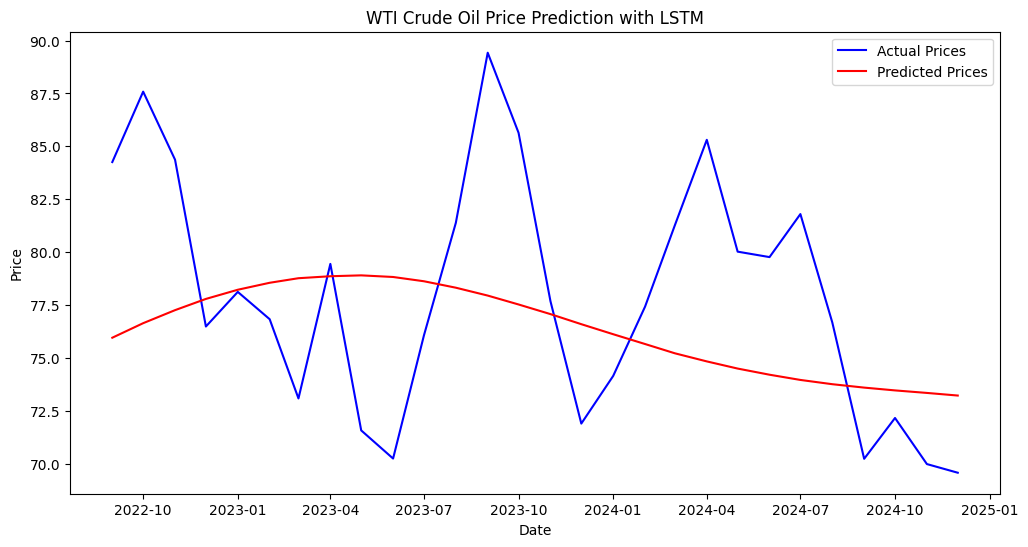

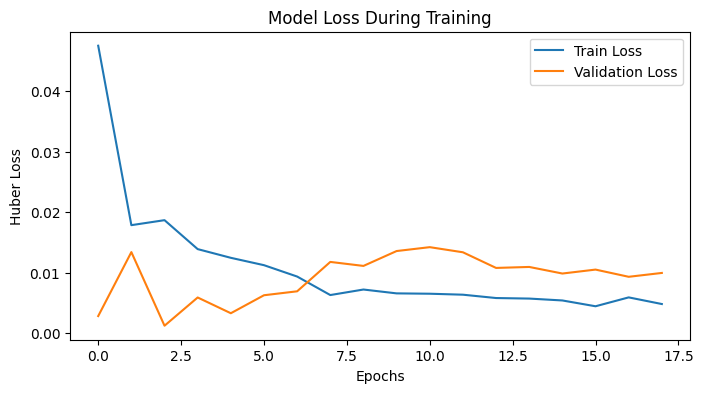

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.losses import Huber


# Load dataset
df = pd.read_csv("/content/training_data_20241224.csv")  # Replace with actual filename
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')  # Convert date column
df.set_index('date', inplace=True)

# Select features and target
features = ['eur_usd', 'inventory', 'production', 'rigs', 'inflation', 'wti_6m_rolling', 'wti_12m_rolling', 'wti_6m_lag']
target = 'wti'

# Scale features and target
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[features + [target]]), columns=features + [target], index=df.index)

# Convert to sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1])  # Features
        y.append(data[i+seq_length, -1])     # Target
    return np.array(X), np.array(y)

seq_length = 90  # Use 90 days for better trend capture
X, y = create_sequences(df_scaled.values, seq_length)

# Train-test split
split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# Build LSTM model
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(seq_length, X.shape[2])),
    Dropout(0.3),
    LSTM(128, activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(50, activation='relu'),
    Dense(1)
])

# Compile model
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss=Huber(delta=1.0))

# Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test), verbose=1,
                    callbacks=[reduce_lr, early_stopping])

# Predictions
y_pred = model.predict(X_test)

# Rescale predictions and actual values
y_test_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_test.reshape(-1, 1)), axis=1))[:, -1]
y_pred_inv = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_pred), axis=1))[:, -1]

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
percentage_rmse = (rmse / np.mean(y_test_inv)) * 100
percentage_mae = (mae / np.mean(y_test_inv)) * 100

print(f'RMSE: {rmse:.2f} ({percentage_rmse:.2f}%)')
print(f'MAE: {mae:.2f} ({percentage_mae:.2f}%)')

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(y_test):], y_test_inv, label='Actual Prices', color='blue')
plt.plot(df.index[-len(y_test):], y_pred_inv, label='Predicted Prices', color='red')
plt.title('WTI Crude Oil Price Prediction with LSTM')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Plot training history
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Huber Loss')
plt.legend()
plt.show()